In [4]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation
from agent import select_action, clever_single_action

%reload_ext autoreload
%autoreload 2

In [5]:
# Init policy Network

from agent import PolicyNet

obs_shape = (3, 5, 5)
policy_net = PolicyNet(obs_shape)
policy_net.load_state_dict(torch.load('policy_net.pth'))
policy_net.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net.to(device)


PolicyNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=75, out_features=100, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=17, bias=True)
)

In [6]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        if type1 == 'Reinforcement Learning Agent':
            action_grid = simulation.configurable_actions_grid(type1=None, type2=type2, type3=type3)

            with torch.no_grad():
                observations, obs_indices = simulation.get_deep_observations(0)
                action = select_action(policy_net, observations)
                action_grid = clever_single_action(simulation, action, obs_indices, type2, type3) 

        else:
            action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)

        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'{type1.capitalize()}'),
        Patch(facecolor='blue', edgecolor='b', label=f'{type2.capitalize()}'),
        Patch(facecolor='green', edgecolor='g', label=f'{type3.capitalize()}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final Population Distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'{type1.capitalize()}', color='red', linestyle='--', marker='o', markersize=4, markevery=10)
    plt.plot(np.arange(iterations), pop2_size, label=f'{type2.capitalize()}', color='blue', marker='x', markersize=4, markevery=7)
    plt.plot(np.arange(iterations), pop3_size, label=f'{type3.capitalize()}', color='green', marker='s', markersize=4, markevery=13)
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_663155/1091598498.py:5: SyntaxWarning: invalid escape sequence '\%'
  all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'


Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 38.88975524902344
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 38.88975524902344

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



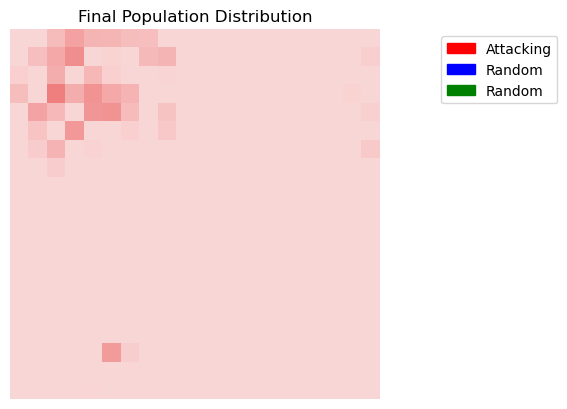

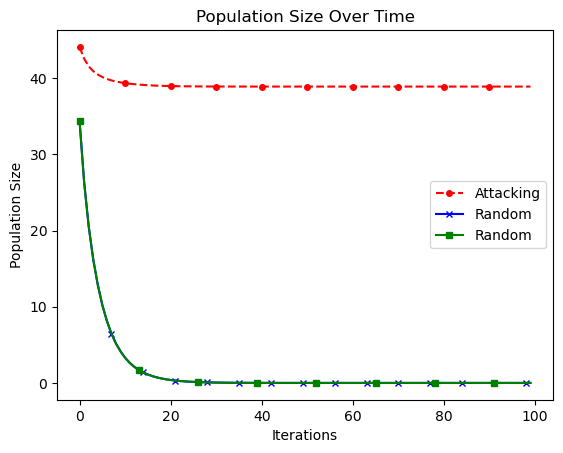

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 6.253650326470961e-07
Population 2: random - 1.1662321412586607e-05
Population 3: random - 1.2375124242680613e-05

Total fitness: 2.466281148372218e-05

Final population %'s fitness:
Population 1: giving - 2.54%
Population 2: random - 47.29%
Population 3: random - 50.18%



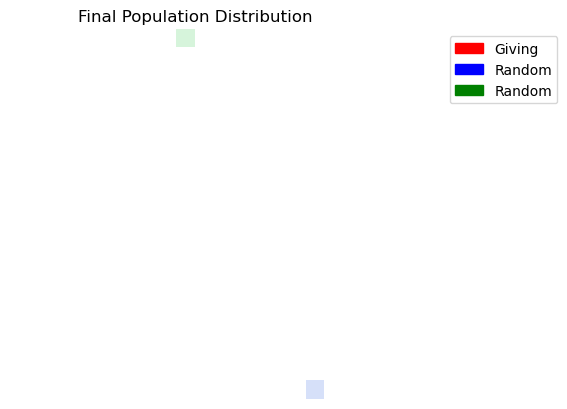

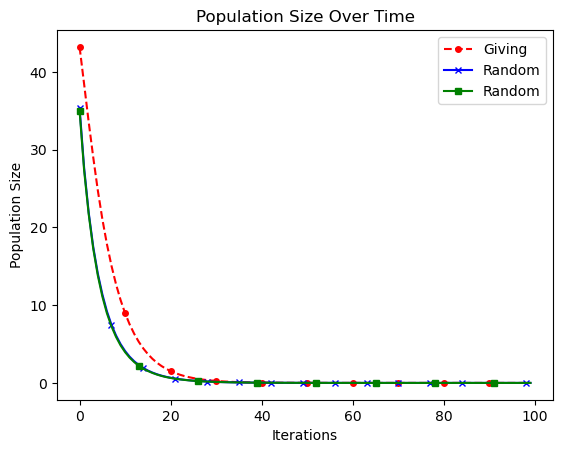

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 9.521773591814053e-08
Population 2: random - 6.4422920331708156e-06
Population 3: random - 6.335170837701298e-06

Total fitness: 1.2872680599684827e-05

Final population %'s fitness:
Population 1: complete - 0.74%
Population 2: random - 50.05%
Population 3: random - 49.21%



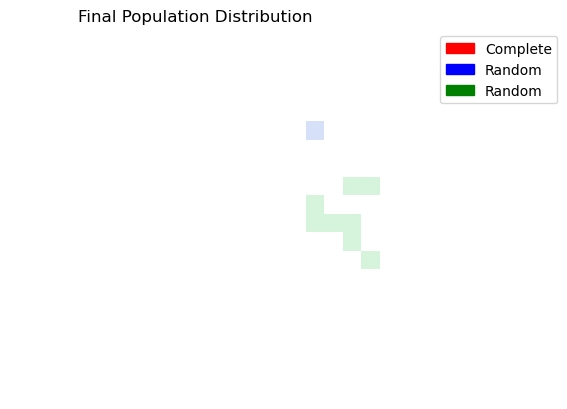

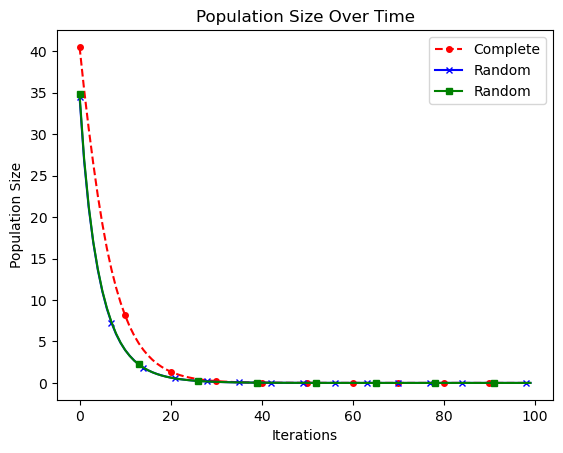

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 5.747425575464149e-07
Population 2: giving - 0.0
Population 3: attacking - 33.69875717163086

Total fitness: 33.69875717163086

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



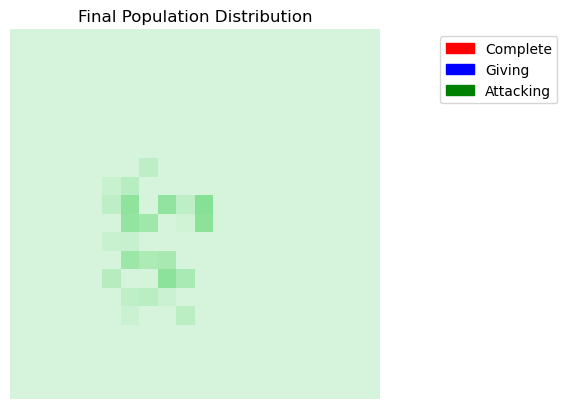

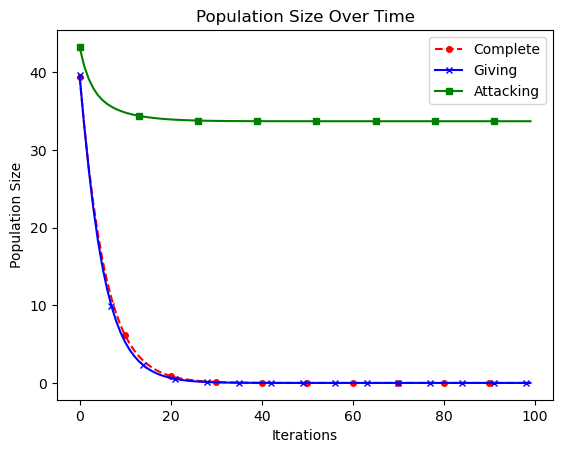

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3318141460418701..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 44.755558013916016
Population 2: random - 8.007828000700101e-06
Population 3: random - 4.070116119692102e-05

Total fitness: 44.75560760498047

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



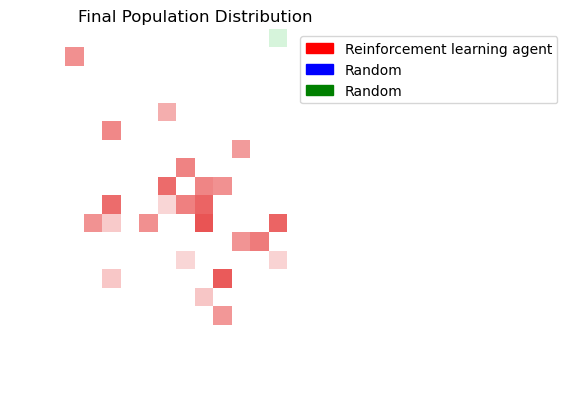

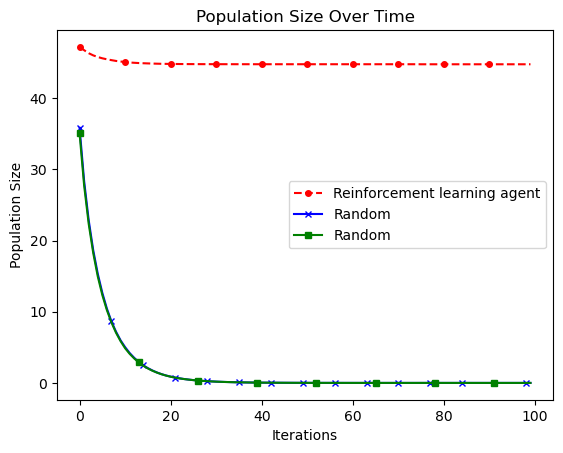

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.533077335357666..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 47.56029510498047
Population 2: giving - 0.03928157314658165
Population 3: giving - 0.037999872118234634

Total fitness: 47.6375732421875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.84%
Population 2: giving - 0.08%
Population 3: giving - 0.08%



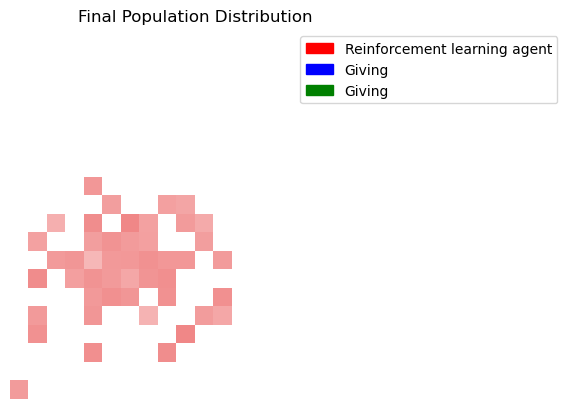

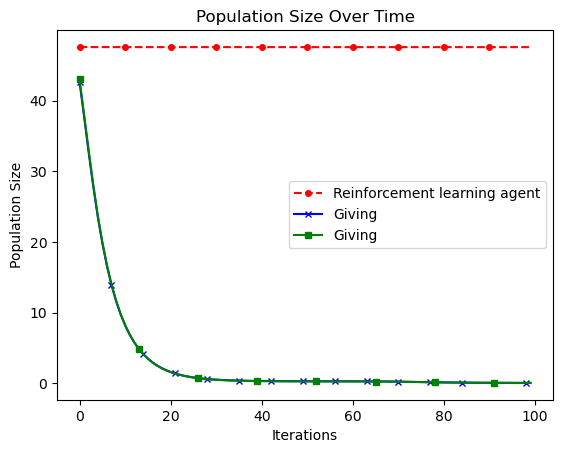

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5051623821258545..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 22.113941192626953
Population 2: attacking - 27.252906799316406
Population 3: attacking - 25.305192947387695

Total fitness: 74.67204284667969

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 29.61%
Population 2: attacking - 36.50%
Population 3: attacking - 33.89%



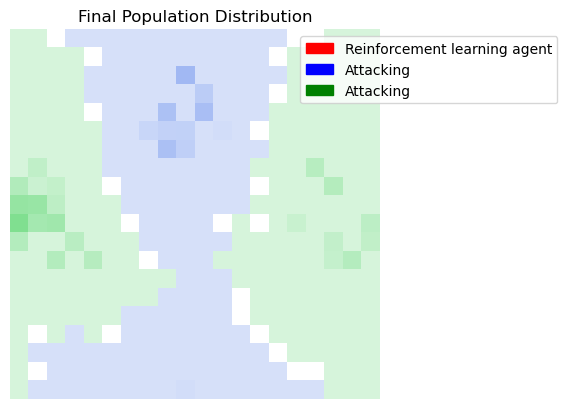

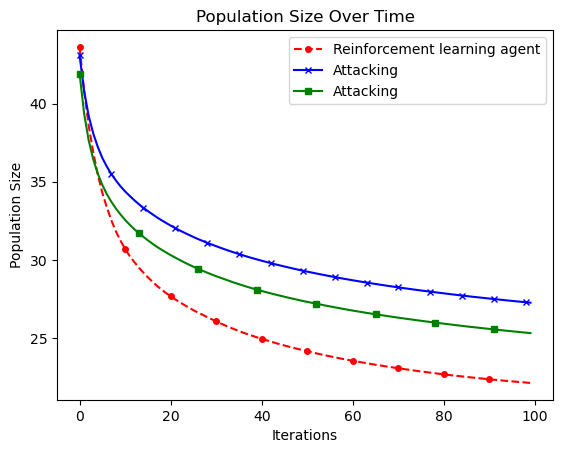

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3616.964599609375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3616.964599609375

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



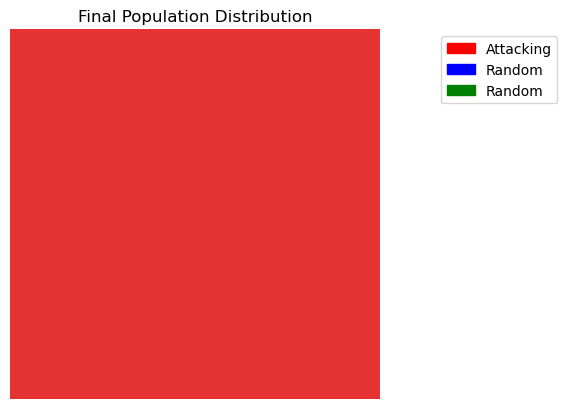

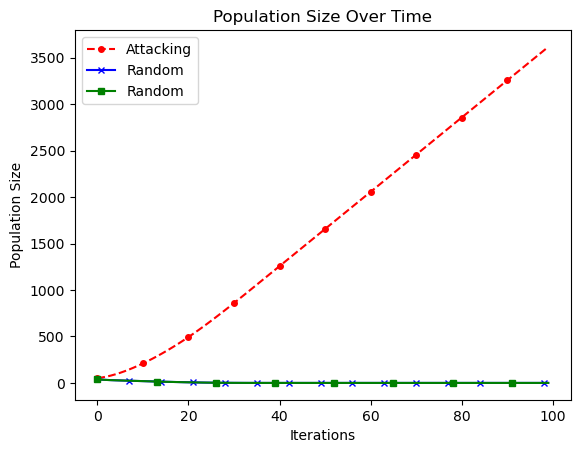

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 224.93328857421875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.93328857421875

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



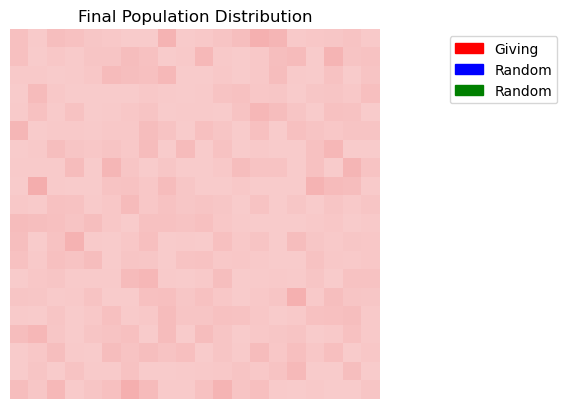

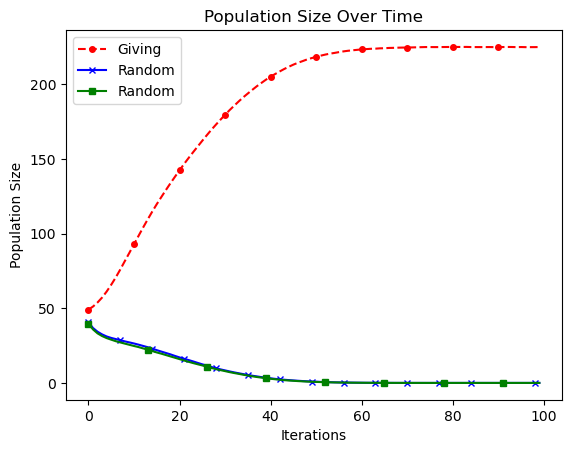

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 225.1535186767578
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 225.1535186767578

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



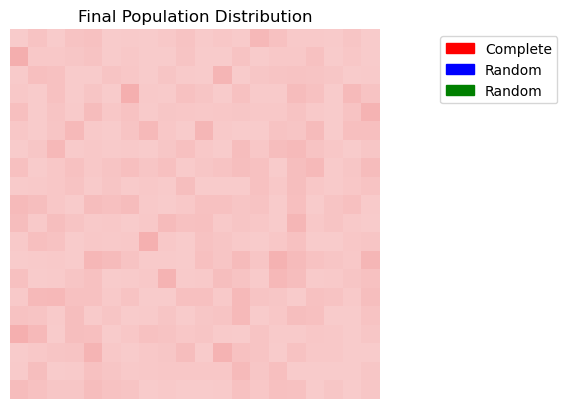

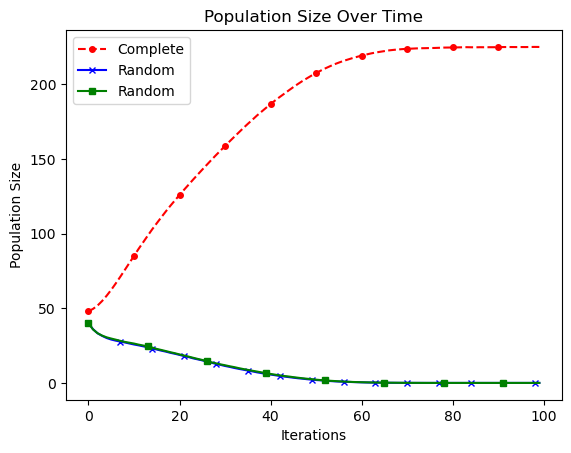

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 3011.860107421875

Total fitness: 3011.860107421875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



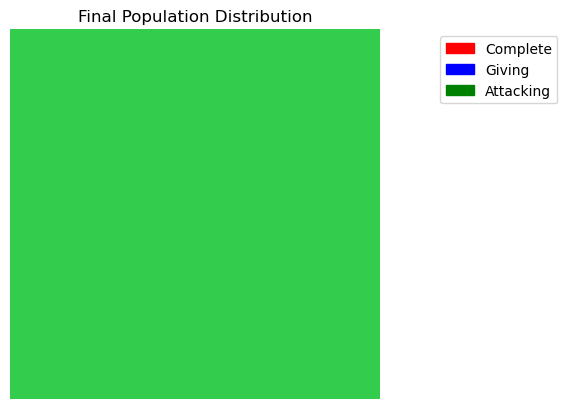

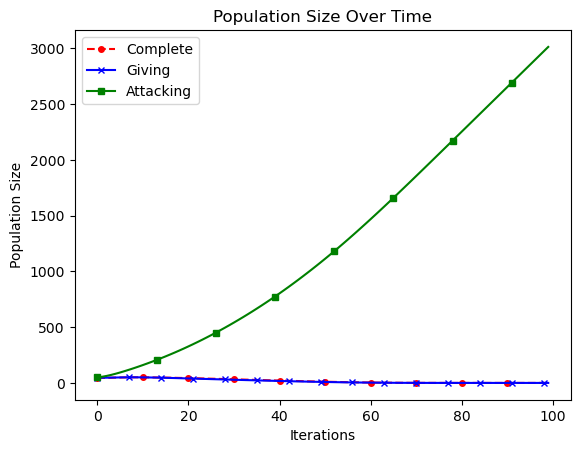

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 456.6156311035156
Population 2: random - 45.73228073120117
Population 3: random - 44.51675796508789

Total fitness: 546.8646850585938

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.50%
Population 2: random - 8.36%
Population 3: random - 8.14%



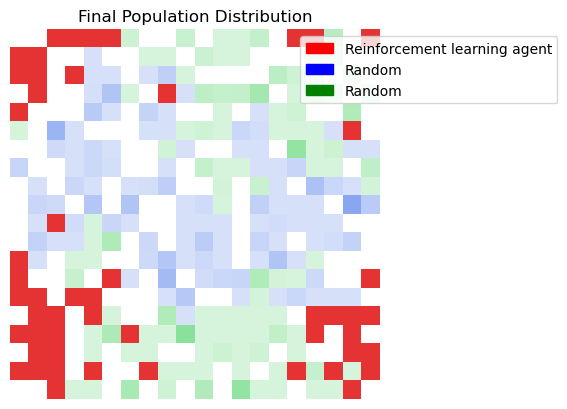

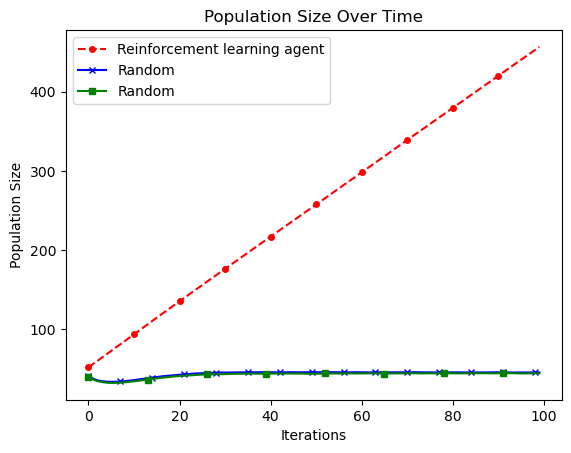

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 509.38397216796875
Population 2: giving - 107.89549255371094
Population 3: giving - 107.55372619628906

Total fitness: 724.8331909179688

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 70.28%
Population 2: giving - 14.89%
Population 3: giving - 14.84%



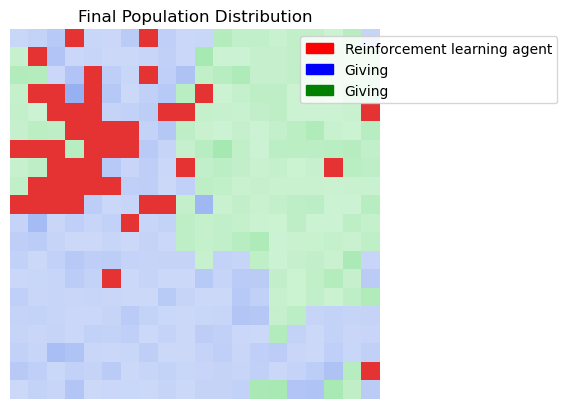

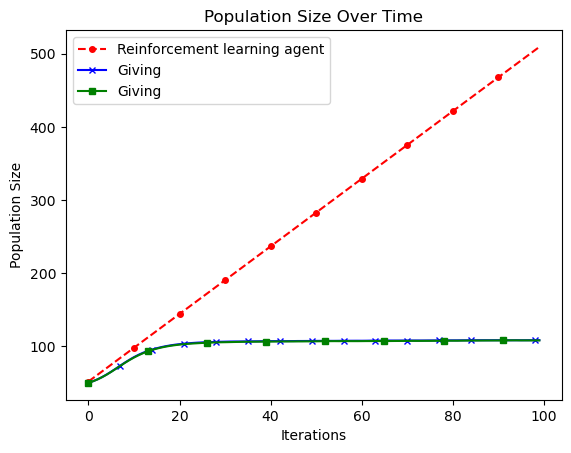

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.8576393723487854
Population 2: attacking - 1278.7919921875
Population 3: attacking - 1267.9864501953125

Total fitness: 2547.63623046875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.03%
Population 2: attacking - 50.20%
Population 3: attacking - 49.77%



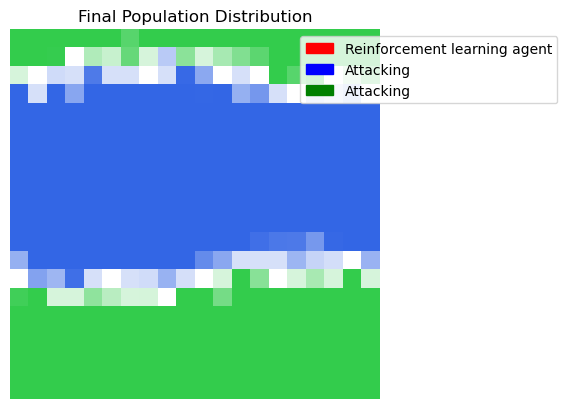

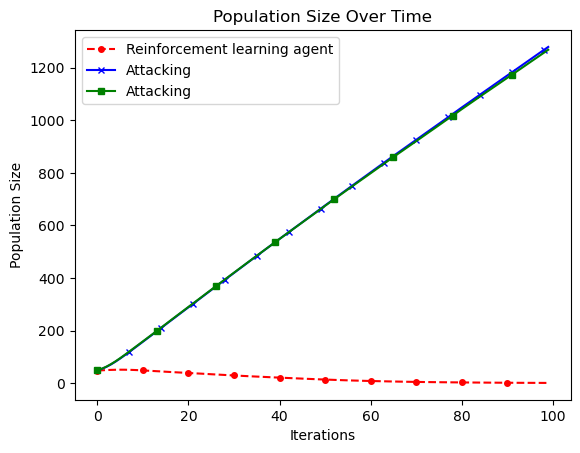

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.174415588378906
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.174415588378906

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



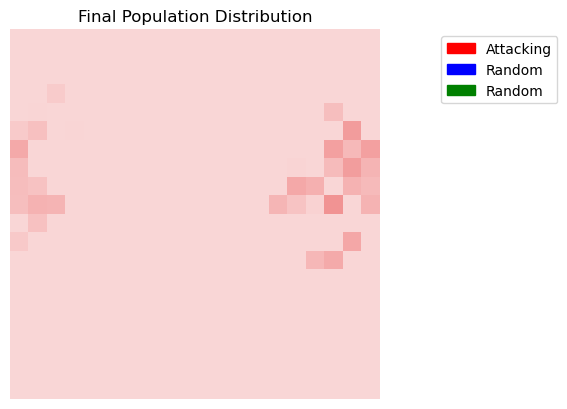

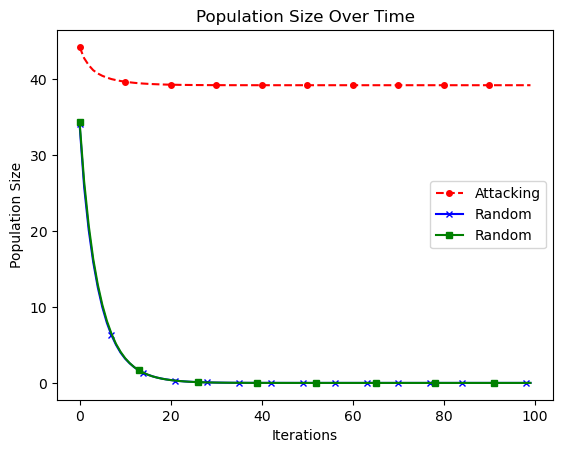

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 5.265404183774081e-07
Population 2: random - 1.1050670764234383e-05
Population 3: random - 1.08040339910076e-05

Total fitness: 2.2381245798896998e-05

Final population %'s fitness:
Population 1: giving - 2.35%
Population 2: random - 49.37%
Population 3: random - 48.27%



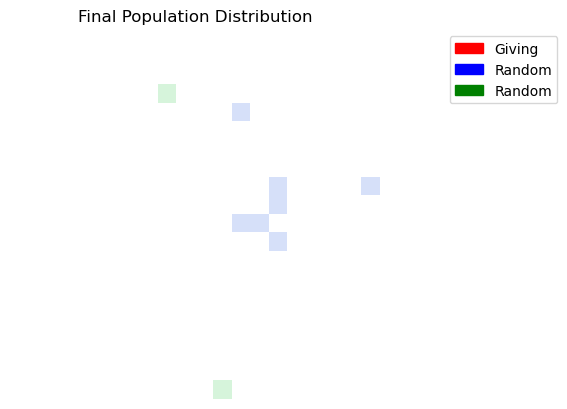

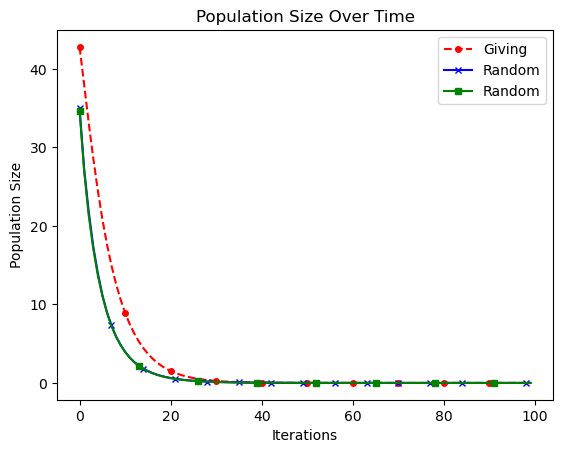

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 8.418557939648963e-08
Population 2: random - 6.555727395607391e-06
Population 3: random - 4.915423687634757e-06

Total fitness: 1.1555336641322356e-05

Final population %'s fitness:
Population 1: complete - 0.73%
Population 2: random - 56.73%
Population 3: random - 42.54%



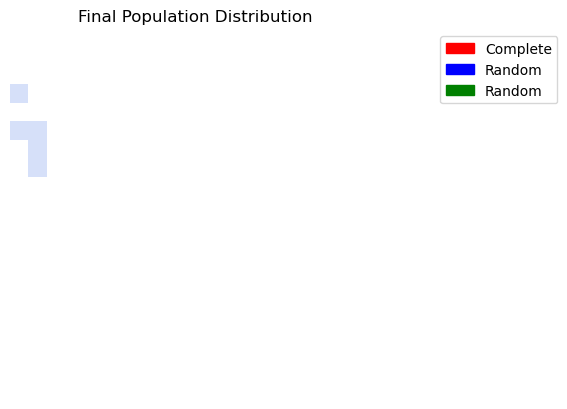

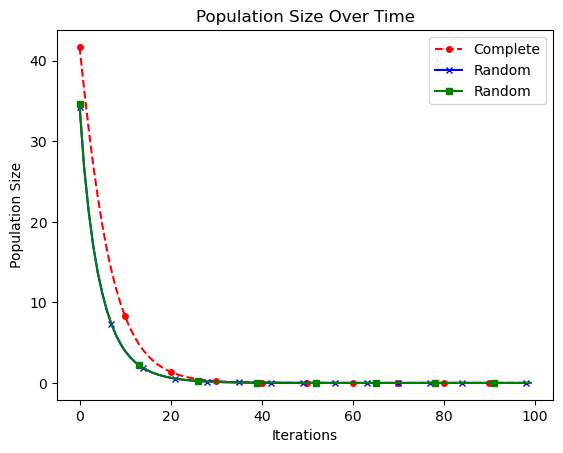

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 32.71877670288086

Total fitness: 32.71877670288086

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



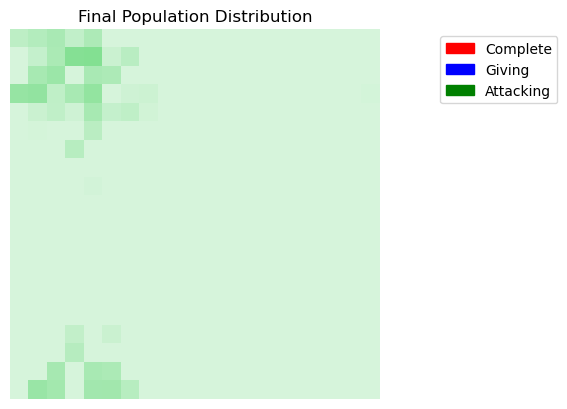

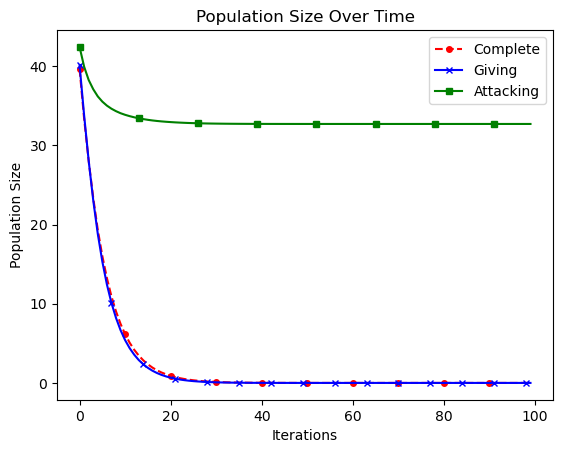

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4613656044006348..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 43.64299011230469
Population 2: random - 7.292187547136564e-06
Population 3: random - 1.0189821296080481e-05

Total fitness: 43.643009185791016

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



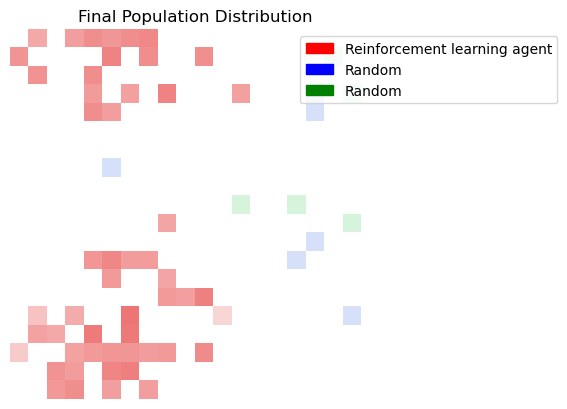

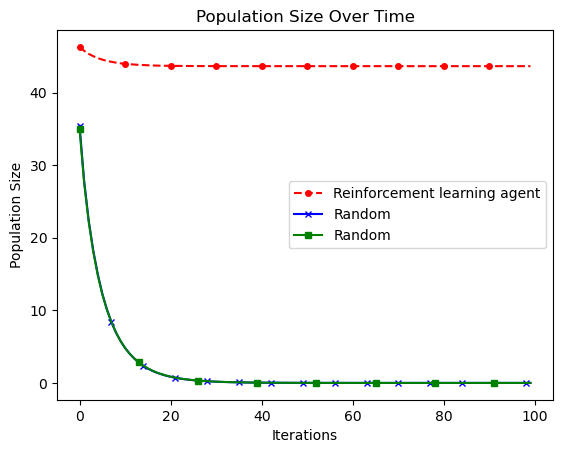

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5081965446472168..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 46.71828079223633
Population 2: giving - 0.04962903633713722
Population 3: giving - 0.04679754376411438

Total fitness: 46.8147087097168

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.79%
Population 2: giving - 0.11%
Population 3: giving - 0.10%



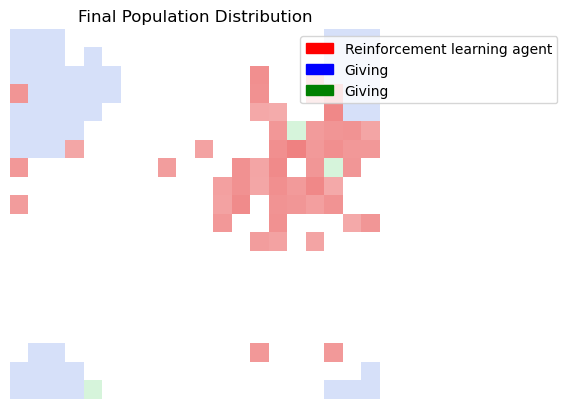

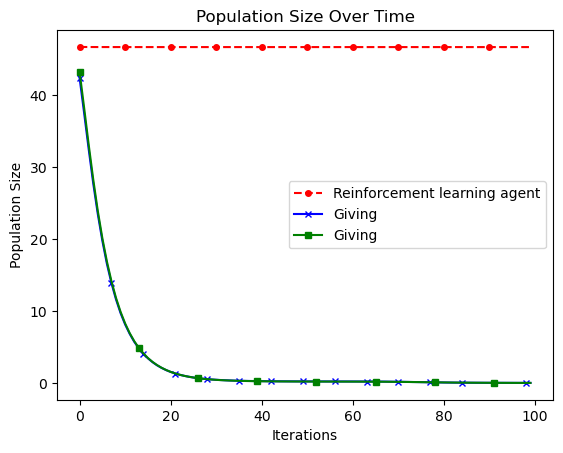

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5257475852966309..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 20.8588809967041
Population 2: attacking - 26.381128311157227
Population 3: attacking - 26.10299301147461

Total fitness: 73.34300231933594

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 28.44%
Population 2: attacking - 35.97%
Population 3: attacking - 35.59%



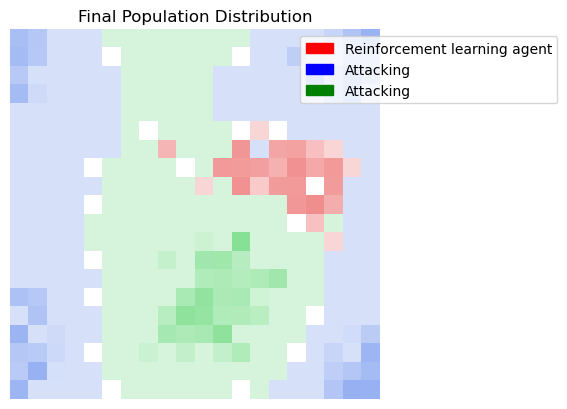

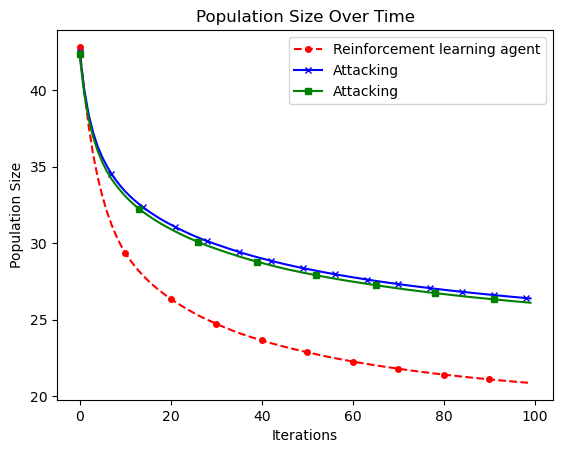

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 3614.11669921875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 3614.11669921875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



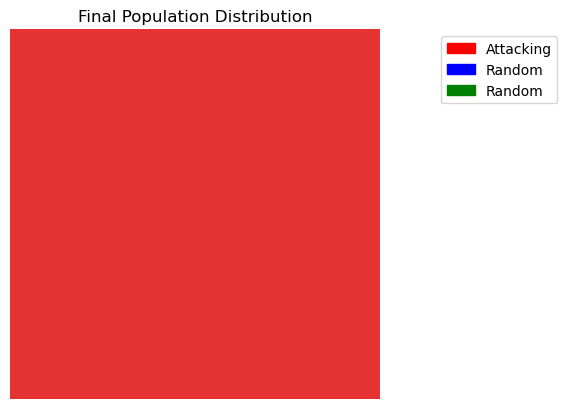

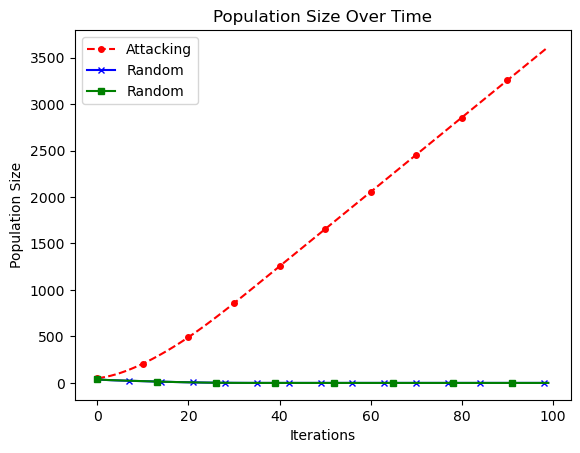

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 224.927734375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 224.927734375

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



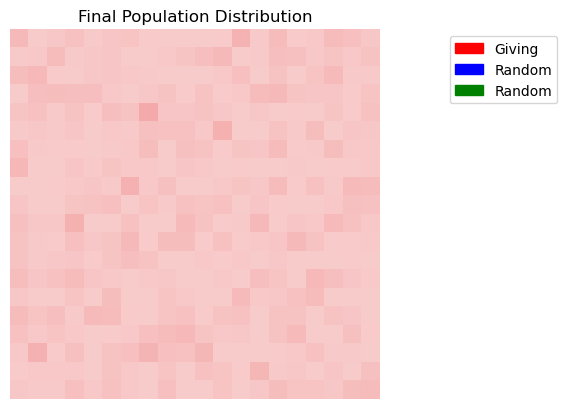

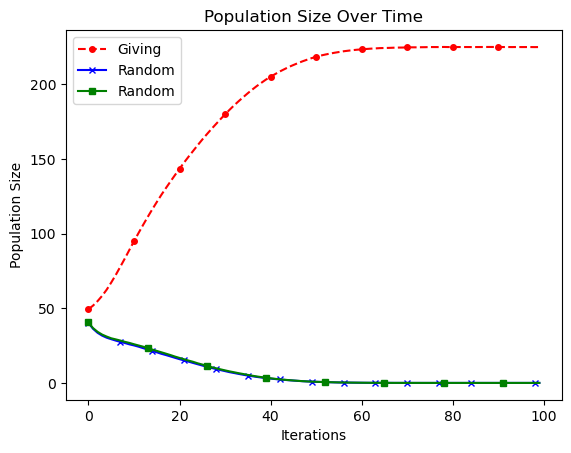

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 225.00062561035156
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 225.00062561035156

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



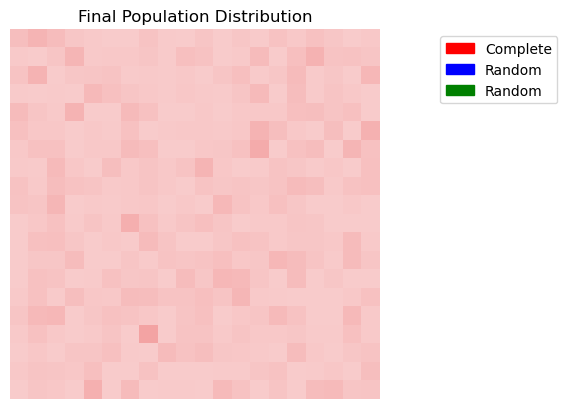

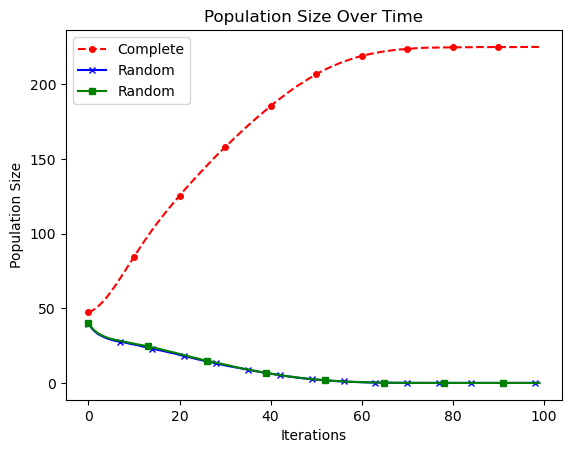

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 2999.44091796875

Total fitness: 2999.44091796875

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



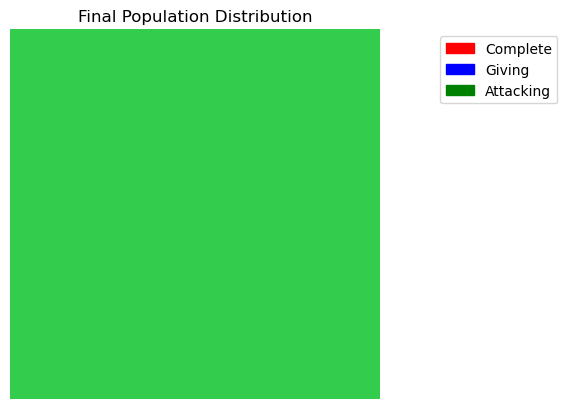

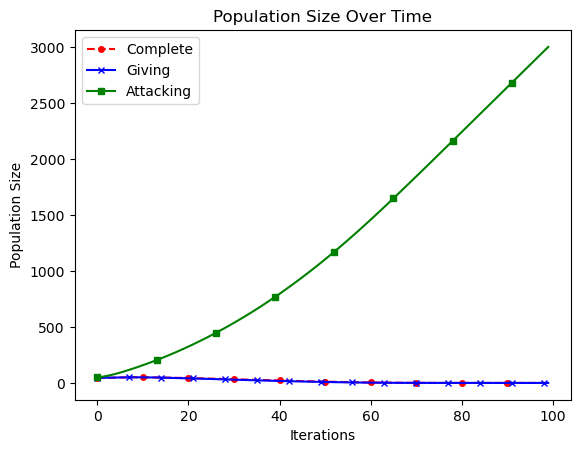

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 445.6891784667969
Population 2: random - 44.216304779052734
Population 3: random - 46.58533477783203

Total fitness: 536.4908447265625

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 83.07%
Population 2: random - 8.24%
Population 3: random - 8.68%



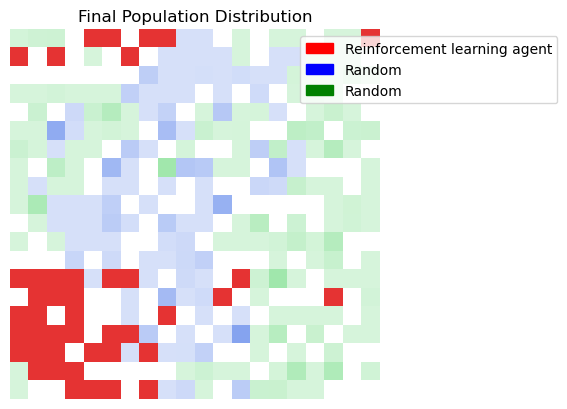

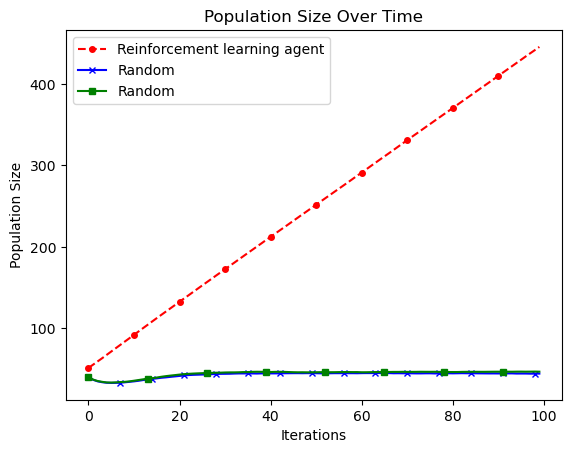

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 515.0496826171875
Population 2: giving - 106.5120620727539
Population 3: giving - 108.80099487304688

Total fitness: 730.36279296875

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 70.52%
Population 2: giving - 14.58%
Population 3: giving - 14.90%



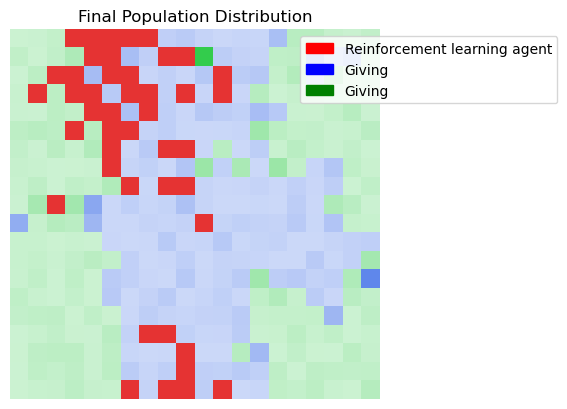

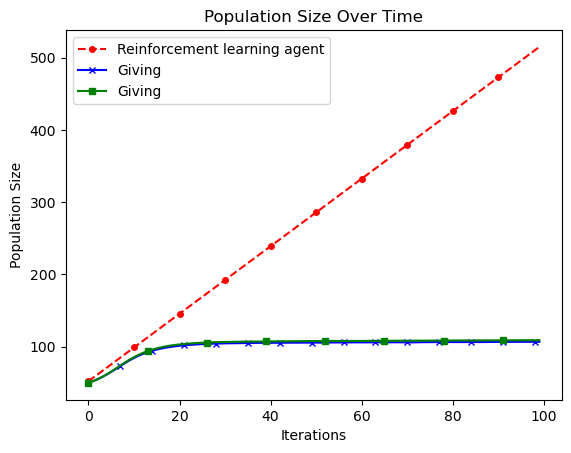

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 1.0229026079177856
Population 2: attacking - 1277.0965576171875
Population 3: attacking - 1260.4664306640625

Total fitness: 2538.5859375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.04%
Population 2: attacking - 50.31%
Population 3: attacking - 49.65%



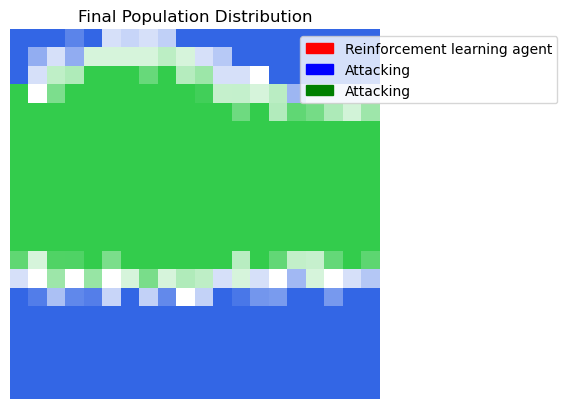

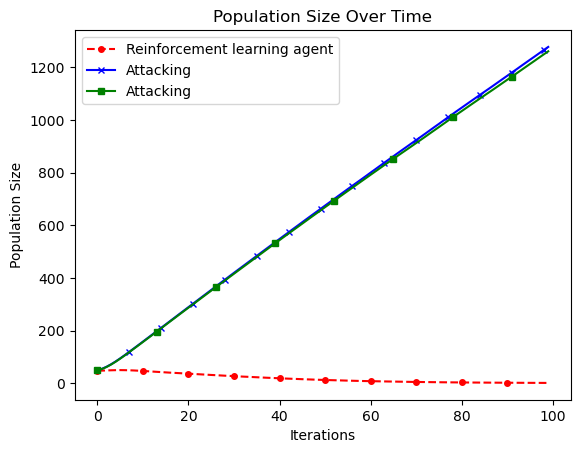

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 39.52668762207031
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 39.52668762207031

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



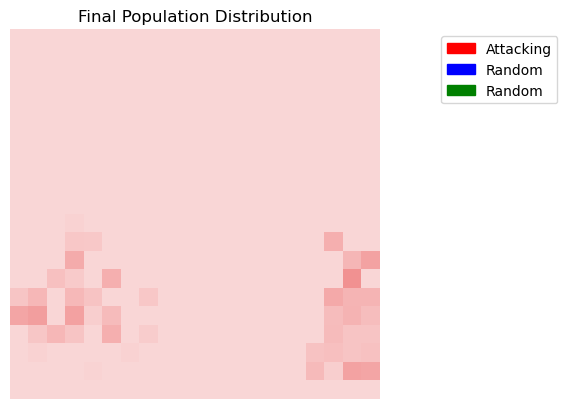

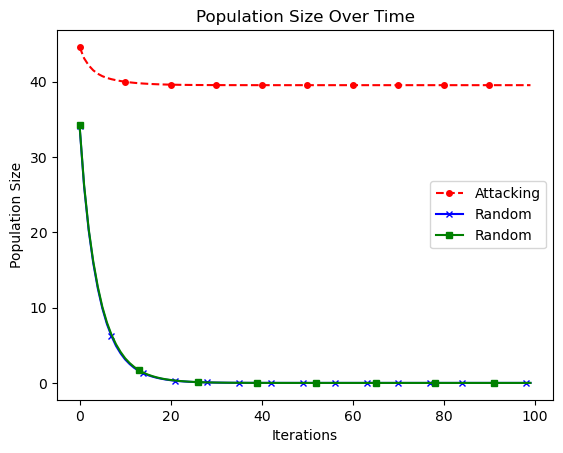

Creating simulation: giving vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: giving - 5.548165518121095e-07
Population 2: random - 1.0728067536547314e-05
Population 3: random - 1.181006427941611e-05

Total fitness: 2.3092947230907157e-05

Final population %'s fitness:
Population 1: giving - 2.40%
Population 2: random - 46.46%
Population 3: random - 51.14%



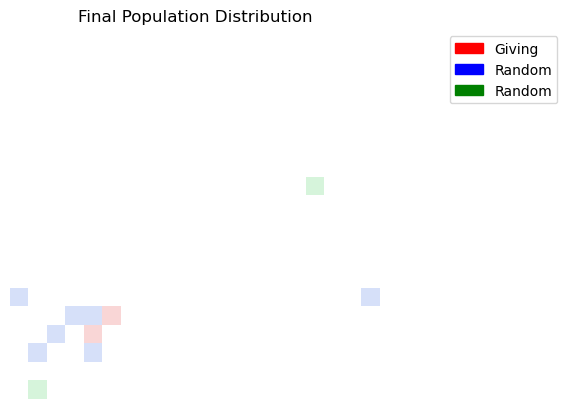

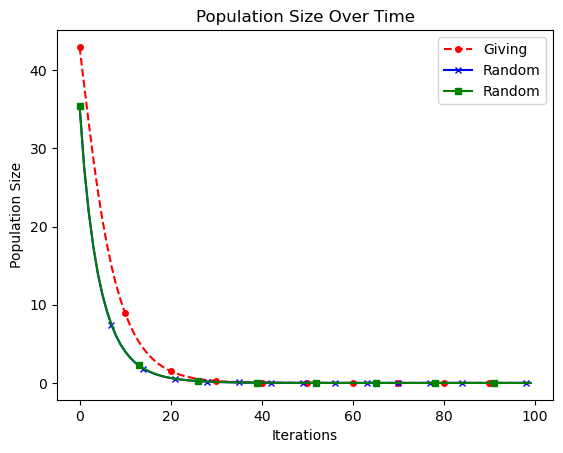

Creating simulation: complete vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.8400000125169754..1.0000000149011612].



Final population fitness:
Population 1: complete - 1.3765252049324772e-07
Population 2: random - 5.048591901868349e-06
Population 3: random - 6.257734185055597e-06

Total fitness: 1.144397901953198e-05

Final population %'s fitness:
Population 1: complete - 1.20%
Population 2: random - 44.12%
Population 3: random - 54.68%



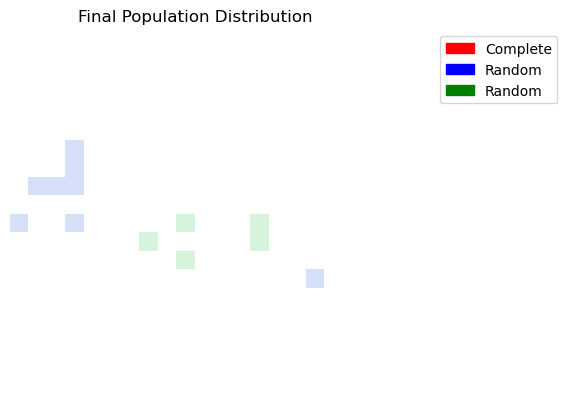

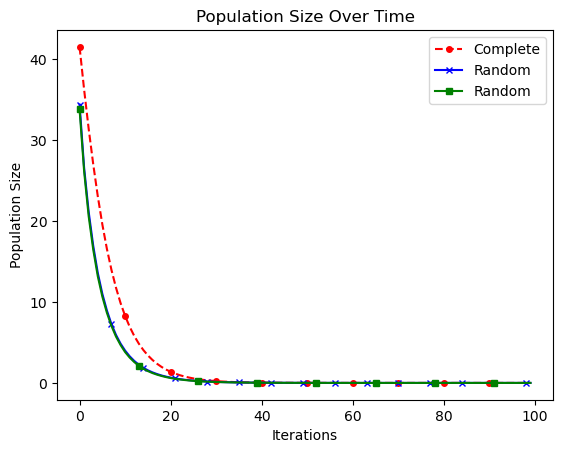

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 33.37815856933594

Total fitness: 33.37815856933594

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



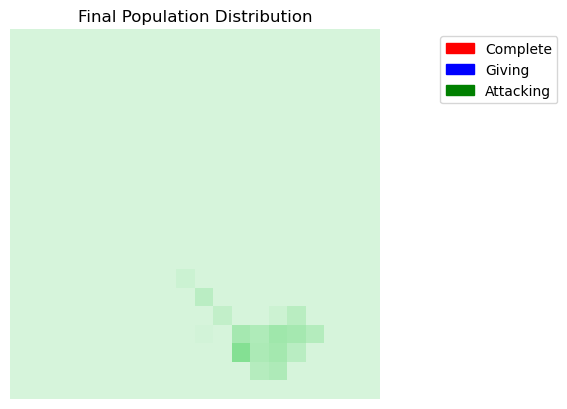

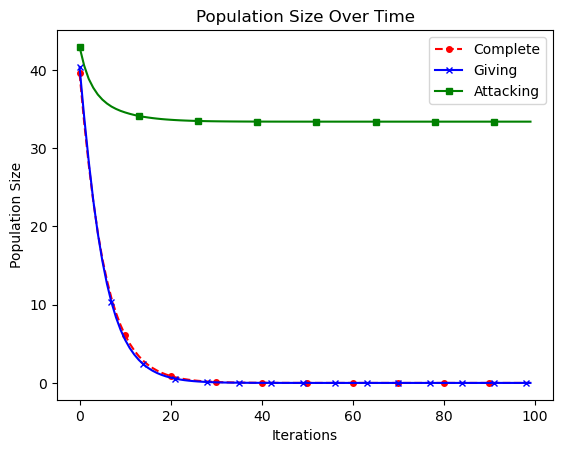

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4126406669616699..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 45.33409118652344
Population 2: random - 7.076833298924612e-06
Population 3: random - 6.416223641281249e-06

Total fitness: 45.3341064453125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



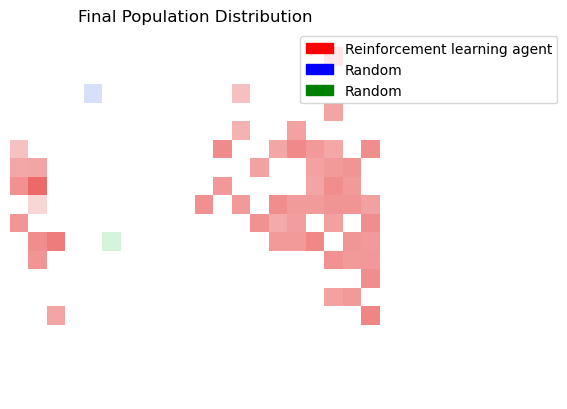

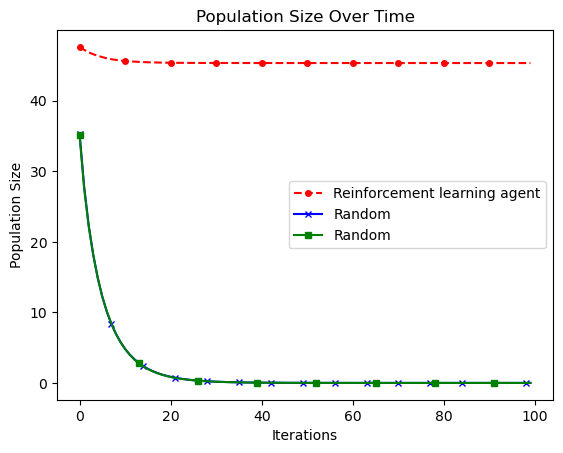

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4553560733795166..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 47.4141731262207
Population 2: giving - 0.025573471561074257
Population 3: giving - 0.04579450190067291

Total fitness: 47.48554229736328

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 99.85%
Population 2: giving - 0.05%
Population 3: giving - 0.10%



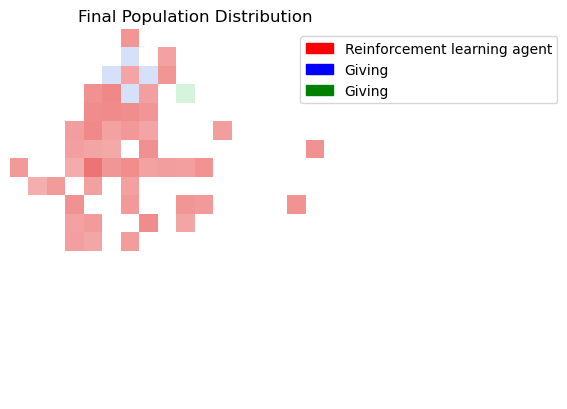

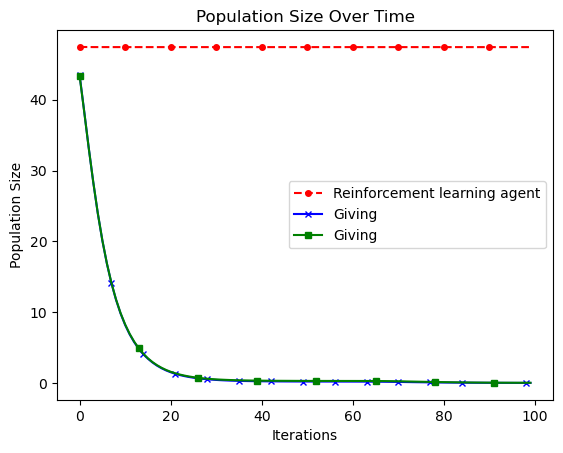

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4528868675231934..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 22.225908279418945
Population 2: attacking - 26.60078239440918
Population 3: attacking - 26.590869903564453

Total fitness: 75.41755676269531

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 29.47%
Population 2: attacking - 35.27%
Population 3: attacking - 35.26%



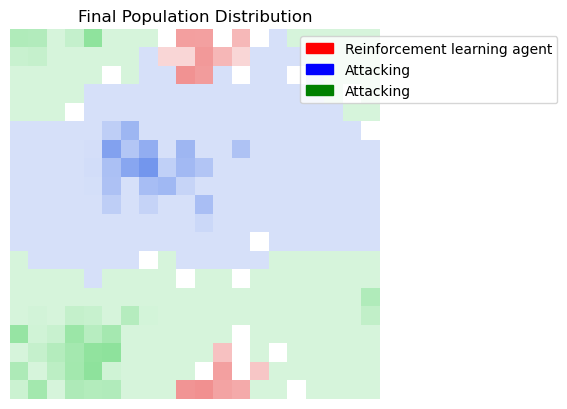

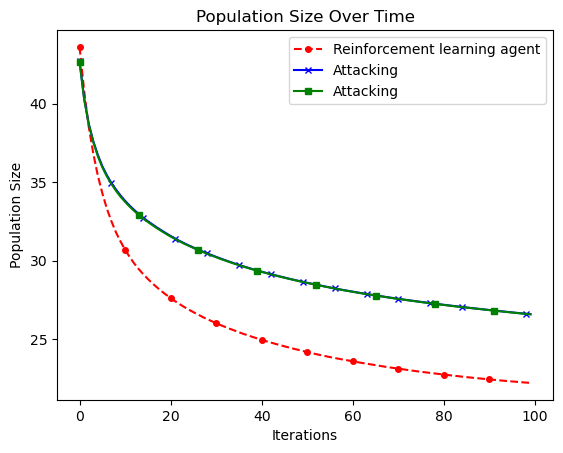

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7199.32373046875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7199.32373046875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



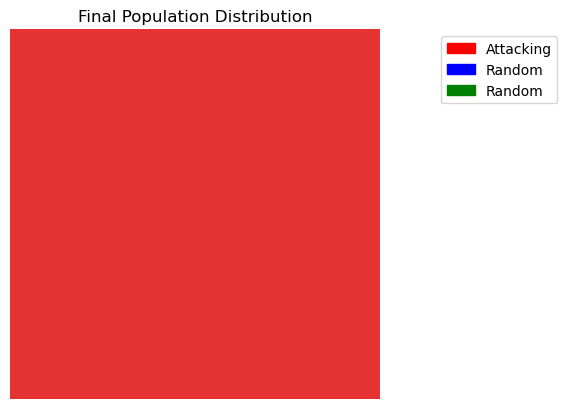

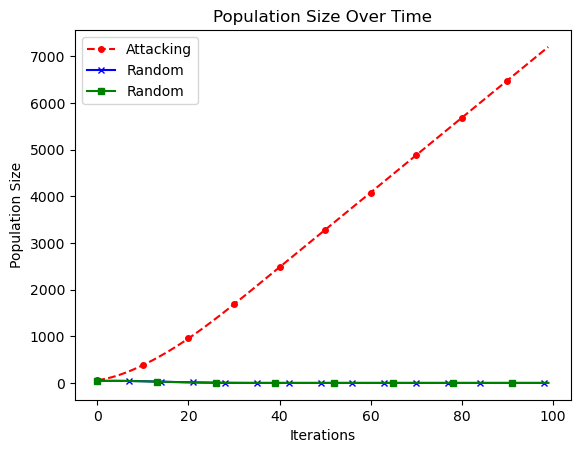

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 449.7453308105469
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.7453308105469

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



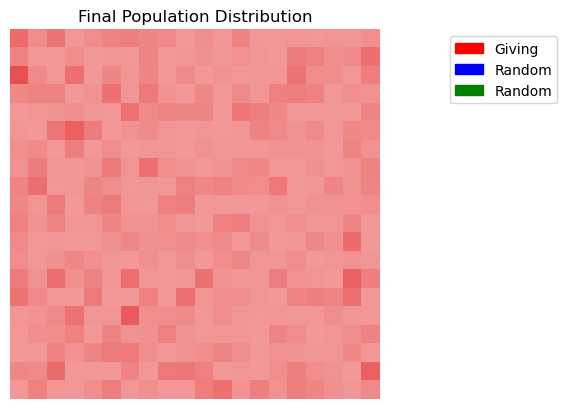

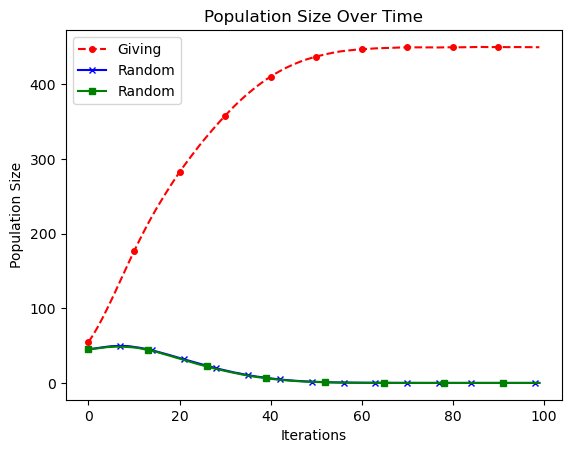

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 449.9195861816406
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.9195861816406

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



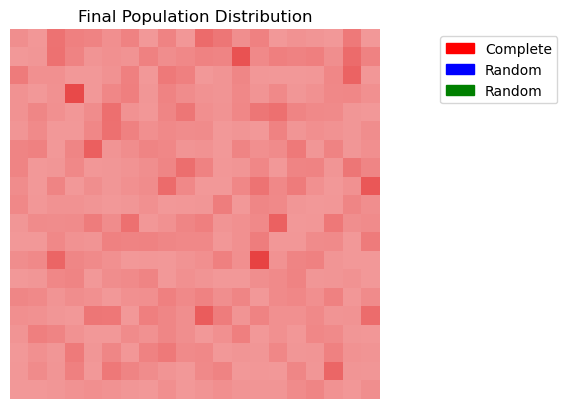

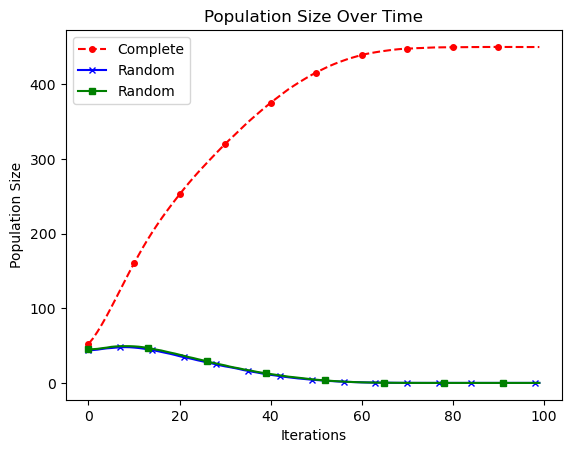

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 6046.64306640625

Total fitness: 6046.64306640625

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



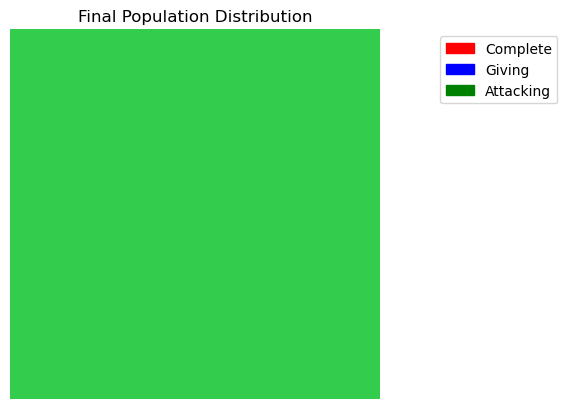

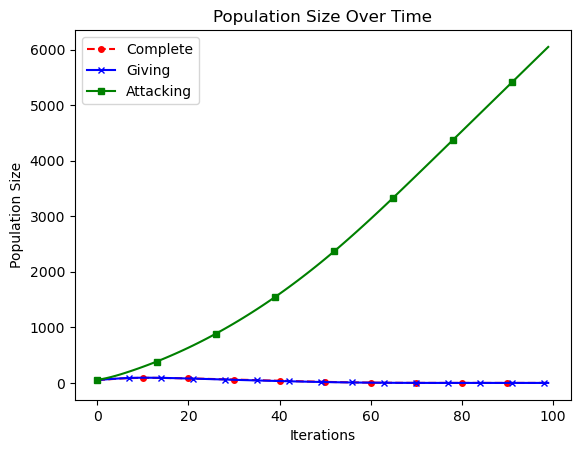

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 849.1551513671875
Population 2: random - 87.31192779541016
Population 3: random - 94.48599243164062

Total fitness: 1030.953125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.37%
Population 2: random - 8.47%
Population 3: random - 9.16%



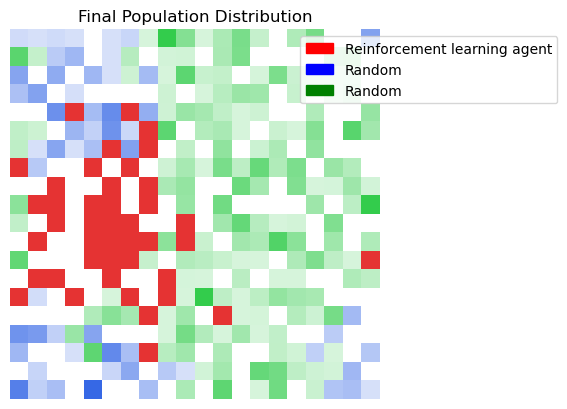

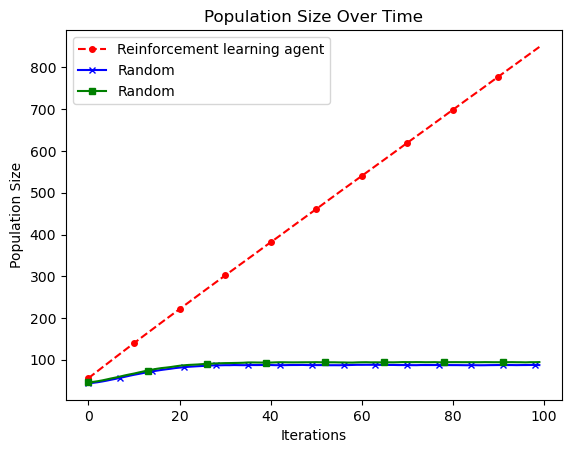

Creating simulation: Reinforcement Learning Agent vs Attacker

Final population fitness:
Population 1: Reinforcement Learning Agent - 985.0877075195312
Population 2: giving - 215.0689697265625
Population 3: giving - 213.69485473632812

Total fitness: 1413.8515625

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 69.67%
Population 2: giving - 15.21%
Population 3: giving - 15.11%



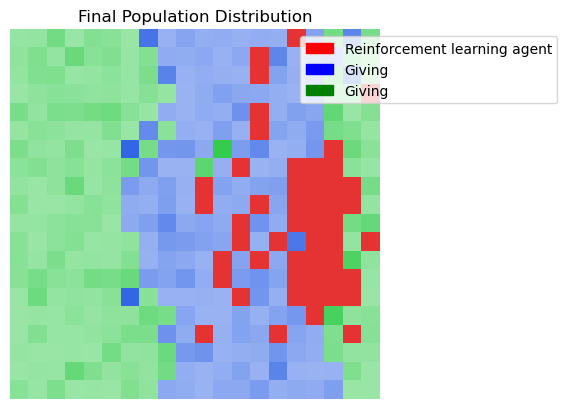

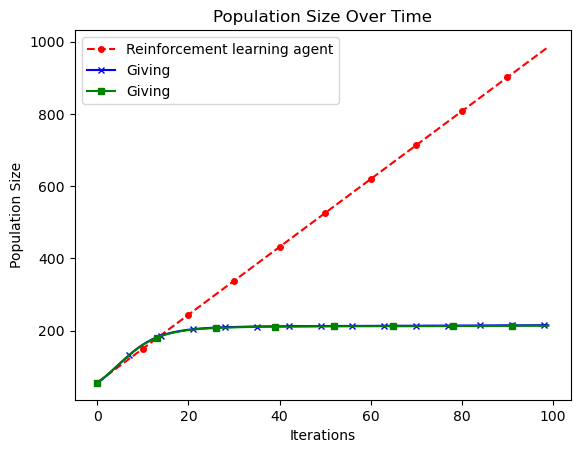

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.4874657690525055
Population 2: attacking - 2580.22265625
Population 3: attacking - 2494.958984375

Total fitness: 5075.6689453125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.01%
Population 2: attacking - 50.84%
Population 3: attacking - 49.16%



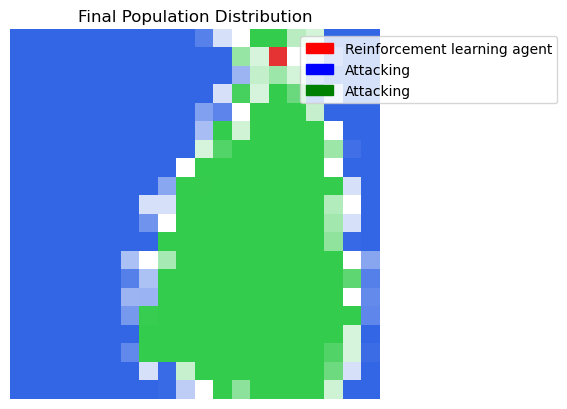

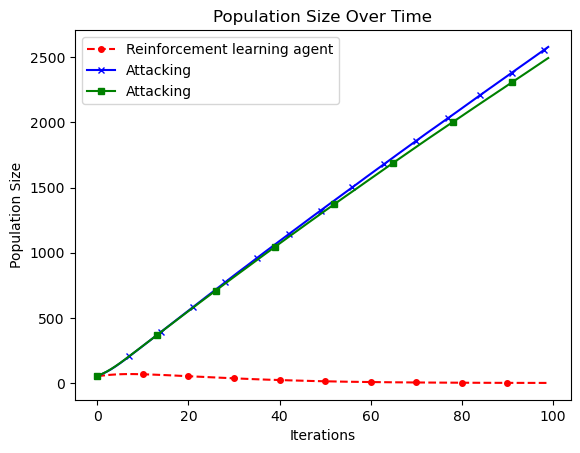

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 7212.2919921875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 7212.2919921875

Final population %'s fitness:
Population 1: attacking - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



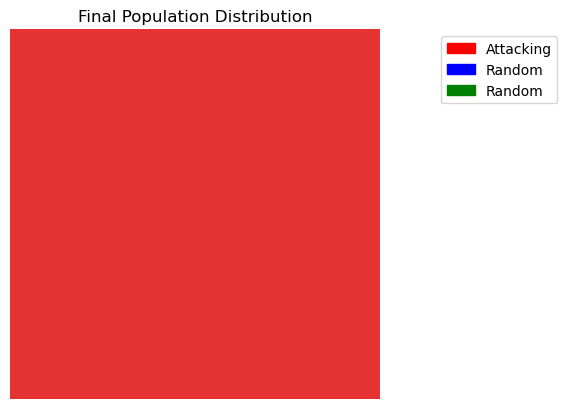

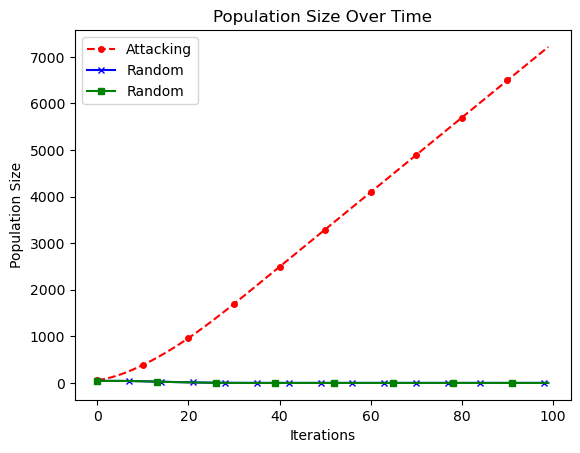

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 449.84515380859375
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.84515380859375

Final population %'s fitness:
Population 1: giving - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



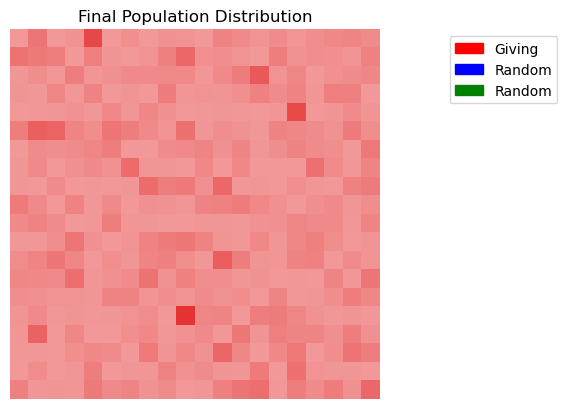

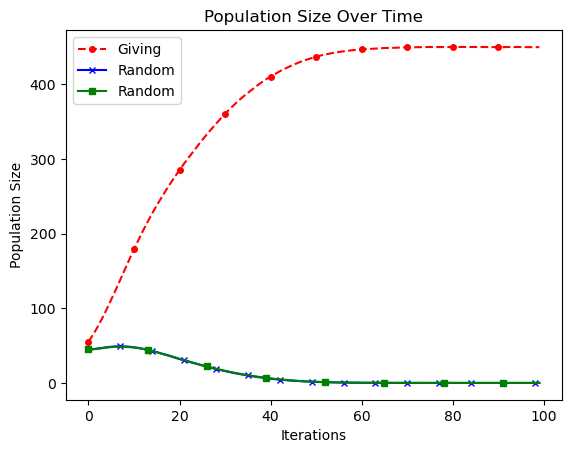

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 449.875
Population 2: random - 0.0
Population 3: random - 0.0

Total fitness: 449.875

Final population %'s fitness:
Population 1: complete - 100.00%
Population 2: random - 0.00%
Population 3: random - 0.00%



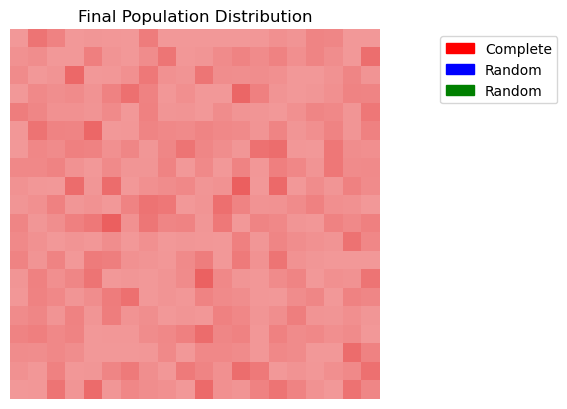

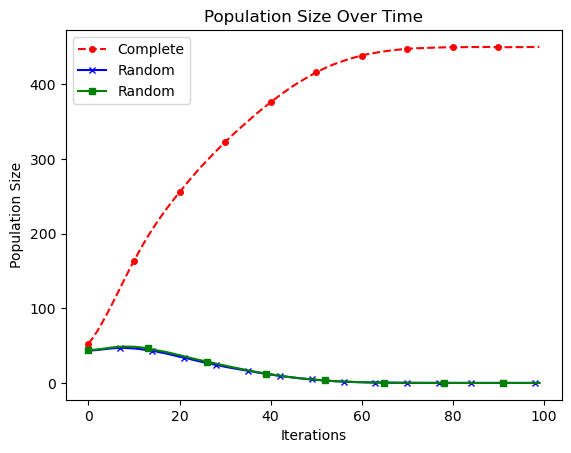

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 0.0
Population 2: giving - 0.0
Population 3: attacking - 6043.50537109375

Total fitness: 6043.50537109375

Final population %'s fitness:
Population 1: complete - 0.00%
Population 2: giving - 0.00%
Population 3: attacking - 100.00%



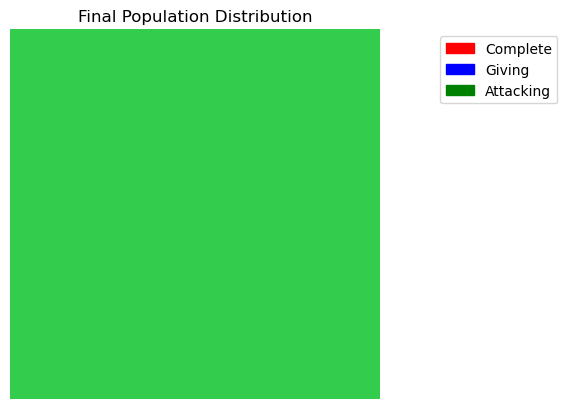

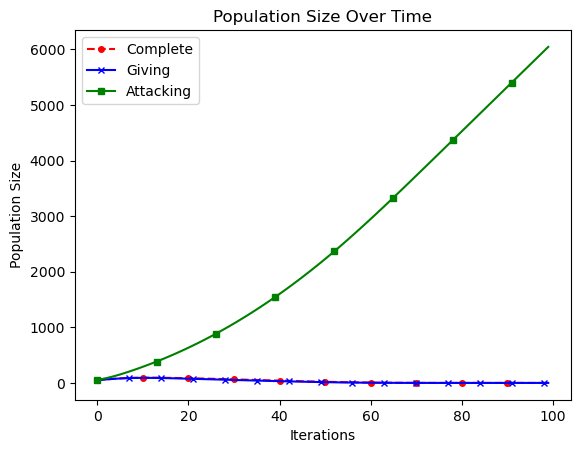

Creating simulation: Reinforcement Learning Agent vs random


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 836.4984130859375
Population 2: random - 94.44554901123047
Population 3: random - 87.62610626220703

Total fitness: 1018.570068359375

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 82.12%
Population 2: random - 9.27%
Population 3: random - 8.60%



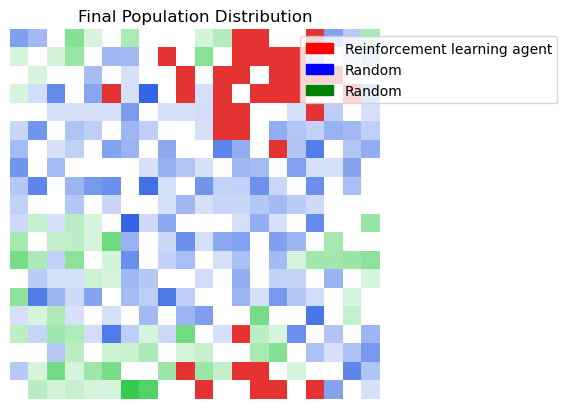

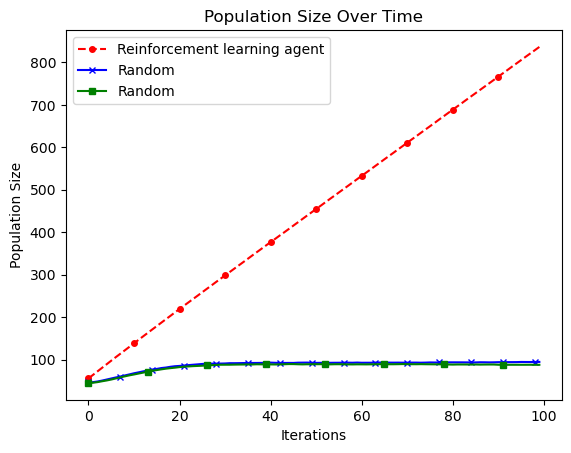

Creating simulation: Reinforcement Learning Agent vs Attacker


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 978.0365600585938
Population 2: giving - 216.66851806640625
Population 3: giving - 213.74269104003906

Total fitness: 1408.44775390625

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 69.44%
Population 2: giving - 15.38%
Population 3: giving - 15.18%



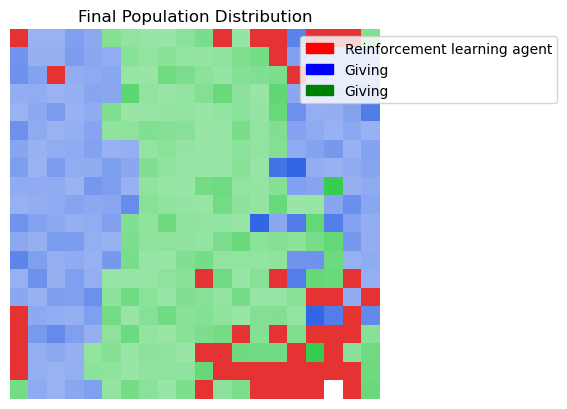

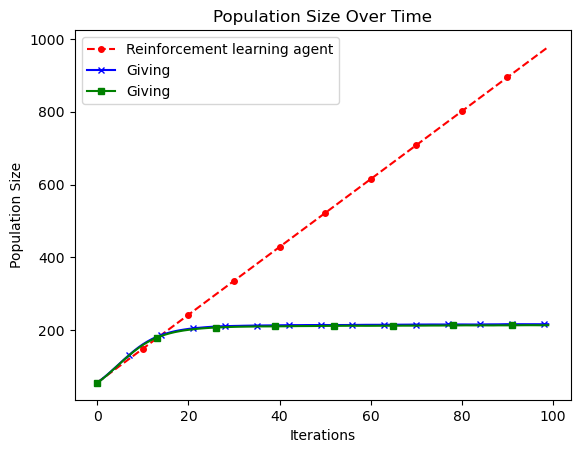

Creating simulation: Reinforcement Learning Agent vs Giving


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2..1.0000000149011612].



Final population fitness:
Population 1: Reinforcement Learning Agent - 0.1417340487241745
Population 2: attacking - 2588.022216796875
Population 3: attacking - 2482.80908203125

Total fitness: 5070.97314453125

Final population %'s fitness:
Population 1: Reinforcement Learning Agent - 0.00%
Population 2: attacking - 51.04%
Population 3: attacking - 48.96%



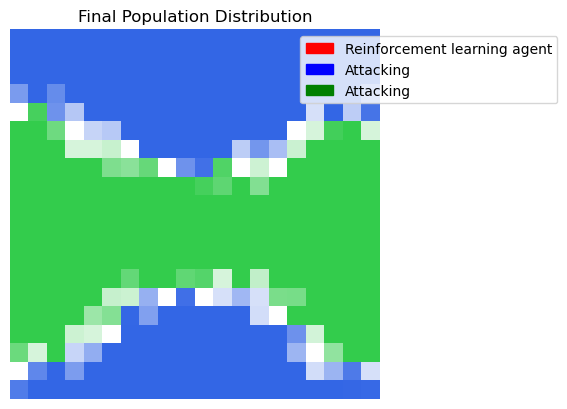

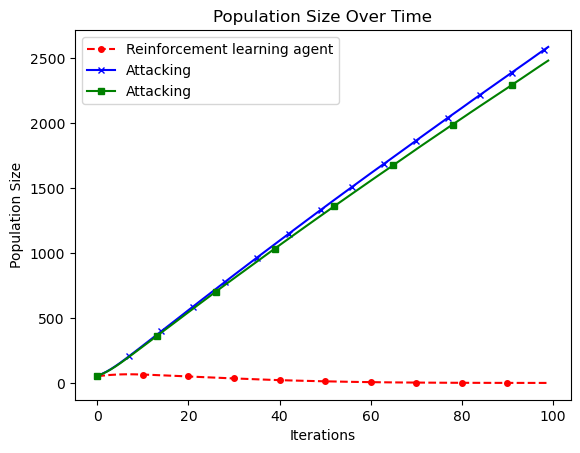

In [7]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 100

# Simulation parameters
nb_batches = 300
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Complete vs Giving vs Attacking\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Random"
    print("Creating simulation: Reinforcement Learning Agent vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='random', type3='random', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Attacker")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsAttacker')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='giving', type3='giving', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Giving\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "Clever vs Attacker"
    print("Creating simulation: Reinforcement Learning Agent vs Giving")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'Reinforcement Learning AgentVsGiving')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='Reinforcement Learning Agent', type2='attacking', type3='attacking', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - Reinforcement Learning Agent vs Attacker\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
